# 3.5 EDA on the four-ticker corpus

`3.4` ended by refusing to pick a winner. Every configuration it tried ran into the same wall: the
corpus was too small and too bursty to tell a real effect from noise. Its handoff was not a fourth
modelling iteration, it was to fix the collection and come back with more data.

That has now happened. The fetch was fixed, three more tickers were added, and the market and merge
layers were extracted into the package so every ticker runs the same way. The corpus went from 1,976
articles on one ticker to 41,298 rows on four.

This notebook is `3.0` run again on that corpus. Same questions: did the merge do what it claims, do
the labels and features have a shape a classifier can learn from, and is anything corrupted, leaked,
or missing in a way that would make a later result fiction. On top of that, it checks the specific
problems `3.0` through `3.4` recorded and left open, one section each, to see which the new data
actually fixed.

Nothing here trains a model. The output is a decision about what iteration four should do.


### 0. Setup

Imports and the files this notebook reads: one merged table per ticker, plus the pooled table that
stacks all four. The merge pipeline wrote them, and every number below comes from those files rather
than from anything recomputed here.


In [1]:
import re
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

from stock_predictor.config import (
    FIGURES_DIR,
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    RAW_OHLCV_PATH,
    report_dir,
)
from stock_predictor.market.evaluate_v2 import row_grouped_splits
from stock_predictor.market.labels import split_ohlcv

TICKERS = ["TSLA", "AAPL", "AMZN", "NVDA"]
SENTIMENT = "fus_conf_graft_floor_mean"
MARKET_FEATURES = [
    "momentum_1d",
    "momentum_5d",
    "momentum_20d",
    "volatility_20d",
    "beta_20d",
    "relative_volume_20d",
    "daily_range_ratio_1d",
    "days_to_earnings",
    "news_volume",
]

sns.set_theme(style="whitegrid")

frames = {
    t: pd.read_parquet(PROCESSED_DATA_DIR / "merged" / t / "merged.parquet")
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
    for t in TICKERS
}
pool = pd.read_parquet(PROCESSED_DATA_DIR / "merged" / "pooled.parquet")

for t in TICKERS:
    print(f"{t}: {frames[t].shape}")
print(f"pooled: {pool.shape}")


2026-08-29 18:47:36.520 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


TSLA: (9073, 37)
AAPL: (7041, 37)
AMZN: (11071, 37)
NVDA: (14113, 37)
pooled: (41298, 37)


### 1. Row counts and the merge

Each ticker's merged table is the inner join of its text features and its market features on
`article_id`. The merge pipeline already checks the key on every run and writes the result into
`reports/merge/`, so this is not re-deriving that work. It confirms the saved files are what those
reports describe: the row counts match, `article_id` is unique inside each ticker, and the pooled
table is the four stacked with nothing lost or duplicated.


In [2]:
rows = []
for t in TICKERS:
    x = frames[t]
    rows.append(
        {
            "ticker": t,
            "rows": len(x),
            "unique_article_id": x["article_id"].nunique(),
            "duplicated": int(x["article_id"].duplicated().sum()),
            "first": x["timestamp_utc"].min().date(),
            "last": x["timestamp_utc"].max().date(),
        }
    )
counts = pd.DataFrame(rows)
print(counts.to_string(index=False))

print(f"\nsum of per-ticker rows : {counts['rows'].sum():,}")
print(f"pooled rows            : {len(pool):,}")
print(f"pooled distinct articles: {pool['article_id'].nunique():,}")
print(f"(article_id, ticker) unique in pooled: {not pool.duplicated(['article_id', 'ticker']).any()}")


ticker  rows  unique_article_id  duplicated      first       last
  TSLA  9073               9073           0 2025-09-01 2026-08-01
  AAPL  7041               7041           0 2025-09-01 2026-08-01
  AMZN 11071              11071           0 2025-08-31 2026-08-01
  NVDA 14113              14113           0 2025-09-01 2026-08-01

sum of per-ticker rows : 41,298
pooled rows            : 41,298
pooled distinct articles: 35,678
(article_id, ticker) unique in pooled: True


Clean. Row counts match the merge reports, no duplicate `article_id` inside any ticker, and the
pooled table is exactly the four stacked.

The pooled table has 41,298 rows but only 35,678 distinct articles. That gap is not a bug and section
12 deals with it: Finnhub returns the same story for every ticker it mentions, so an article about
several companies appears once per ticker, scored toward a different target each time. Inside one
ticker `article_id` is unique; across the pooled table the key is `(article_id, ticker)`.


### 2. Labels and features

36 columns. Four are identity, two are labels, the rest split between the text layer and the market
layer. Two things changed since `3.0` looked at this table and both are worth stating up front.

**The 3-day label is gone.** `3.0` added `label_direction_3d` and measured it, `3.1` dropped the
3-day columns from the model-ready table after finding they carried almost no signal, and the market
pipeline now does not build them at all. There is one label here, not two.

**The shrinkage fix ships in the pipeline.** `3.0` section 9.1 built the small-sample correction by
hand in the notebook and section 13 listed moving it upstream as work still to do. That happened:
`fus_conf_graft_floor_mean` and `fus_trusted_mean` arrive already shrunk, under the plain names, and
`has_ceo_mention` is a real column rather than something re-derived from `.notna()` each time. There
is no `_shrunk` suffix to look for any more.


In [3]:
IDENTITY = ["article_id", "ticker", "timestamp_utc", "source"]
LABELS = ["abnormal_return_1d", "label_direction"]
TEXT_FEATURES = [
    c for c in pool.columns if c not in IDENTITY + LABELS + MARKET_FEATURES + ["session"]
]

print(f"identity ({len(IDENTITY)}): {IDENTITY}")
print(f"labels   ({len(LABELS)}): {LABELS}")
print(f"market   ({len(MARKET_FEATURES) + 1}): {MARKET_FEATURES + ['session']}")
print(f"text     ({len(TEXT_FEATURES)}): {TEXT_FEATURES}")

print(f"\nany column ending _3d? {[c for c in pool.columns if c.endswith('_3d')] or 'none'}")
print(f"any column ending _shrunk? {[c for c in pool.columns if c.endswith('_shrunk')] or 'none'}")
print(f"has_ceo_mention present? {'has_ceo_mention' in pool.columns}")

matches = (np.sign(pool["abnormal_return_1d"]) == pool["label_direction"]).mean()
print(f"\nlabel_direction == sign(abnormal_return_1d) on {matches:.1%} of rows")


identity (4): ['article_id', 'ticker', 'timestamp_utc', 'source']
labels   (2): ['abnormal_return_1d', 'label_direction']
market   (10): ['momentum_1d', 'momentum_5d', 'momentum_20d', 'volatility_20d', 'beta_20d', 'relative_volume_20d', 'daily_range_ratio_1d', 'days_to_earnings', 'news_volume', 'session']
text     (21): ['n_total_sents', 'n_entity_sents', 'n_ceo_sents', 'n_boilerplate_sents', 'entity_share', 'article_length', 'fus_conf_graft_floor_mean', 'fus_conf_graft_floor_median', 'fus_conf_graft_floor_lead', 'fus_conf_graft_floor_top3_pos', 'fus_conf_graft_floor_top3_neg', 'fus_conf_graft_floor_spread', 'fus_ceo_mean', 'has_ceo_mention', 'fus_headline', 'fus_maxmag', 'fus_trusted_mean', 'fus_scorer_gap', 'fus_headline_gap', 'fus_lead_gap', 'session_open']

any column ending _3d? none
any column ending _shrunk? none
has_ceo_mention present? True

label_direction == sign(abnormal_return_1d) on 100.0% of rows


As expected. No `_3d` column, no `_shrunk` suffix, `has_ceo_mention` present as a real column, and
`label_direction` is exactly the sign of the 1-day abnormal return on every row.


### 3. Missingness

Which columns carry NaN, how much, and whether it is the kind that needs handling before training.


In [4]:
missing = pool.isna().mean()
missing = missing[missing > 0].sort_values(ascending=False)
print("columns with any NaN, pooled:")
print((missing * 100).round(2).to_string() if len(missing) else "  none")

print("\nfus_ceo_mean missing, by ticker:")
for t in TICKERS:
    x = frames[t]
    print(f"  {t}: {x['fus_ceo_mean'].isna().mean():.1%} missing, has_ceo_mention true on {x['has_ceo_mention'].mean():.1%}")

agree = (pool["fus_ceo_mean"].notna() == pool["has_ceo_mention"]).mean()
print(f"\nfus_ceo_mean.notna() agrees with has_ceo_mention on {agree:.1%} of rows")

flag, scored = pool["has_ceo_mention"], pool["fus_ceo_mean"].notna()
print(f"  flag true,  score present: {int((flag & scored).sum()):,}")
print(f"  flag true,  score missing: {int((flag & ~scored).sum()):,}")
print(f"  flag false, score present: {int((~flag & scored).sum()):,}")
print(f"  flag false, score missing: {int((~flag & ~scored).sum()):,}")

odd = pool[~flag & scored]
print(f"\nall {len(odd):,} disagreeing rows have n_ceo_sents == 0: {(odd['n_ceo_sents'] == 0).all()}")
print(f"their fus_ceo_mean is exactly 0.0 on only {(odd['fus_ceo_mean'] == 0).mean():.1%} of them")


columns with any NaN, pooled:
fus_ceo_mean        73.64
fus_trusted_mean     0.00

fus_ceo_mean missing, by ticker:
  TSLA: 49.2% missing, has_ceo_mention true on 30.8%
  AAPL: 79.3% missing, has_ceo_mention true on 5.4%
  AMZN: 84.3% missing, has_ceo_mention true on 5.8%
  NVDA: 78.2% missing, has_ceo_mention true on 9.2%

fus_ceo_mean.notna() agrees with has_ceo_mention on 86.0% of rows
  flag true,  score present: 5,114
  flag true,  score missing: 0
  flag false, score present: 5,771
  flag false, score missing: 30,413

all 5,771 disagreeing rows have n_ceo_sents == 0: True
their fus_ceo_mean is exactly 0.0 on only 26.0% of them


Two columns carry NaN, and checking them turned up a real inconsistency.

`fus_ceo_mean` is missing on 73.6% of rows, up from 50.6% in `3.0`. Most of that rise is not a
problem: TSLA sits at 49.2%, close to what `3.0` measured, and the other three run 78% to 84% because
their CEOs are named far less often in coverage than Musk is. That is a fact about the companies.

The problem is that `has_ceo_mention` and `fus_ceo_mean` disagree on 14% of rows, and they are
supposed to describe the same thing. The disagreement is entirely one-sided: 5,771 rows have
`has_ceo_mention` false while still carrying a CEO score, three quarters of those scores non-zero,
and no row has the reverse.

The cause is two different populations, one layer apart.

- `n_ceo_sents`, which `has_ceo_mention` is derived from, counts CEO-**only** sentences:
  `mentions_ceo & ~mentions_target`.
- `fus_ceo_mean` averages over **all** CEO sentences: `mentions_ceo & ~is_boilerplate`.

So an article that only ever names the CEO alongside the company has no CEO-only sentence, and gets
`has_ceo_mention = False`, while still having sentences to score and therefore a real
`fus_ceo_mean`. The column's own docstring says it is robust to the headline-only 0-fill "unlike
`fus_ceo_mean.notna()`", which is true but describes a different mismatch from the one actually here.

So `has_ceo_mention` does not mean what its name says. It means "has a sentence about the CEO that is
not also about the company", which is a narrower and stranger question, and it is the wrong partner
for `fus_ceo_mean`. Section 3.1 fixes it.

The count itself is not the error. `n_ceo_sents` was defined in `2.3` to count CEO-only sentences and
that is a coherent thing to count. The mistake was deriving a general flag from it.

`fus_trusted_mean` is missing on a single row out of 41,298. Not worth a decision either way.


### 3.1 Fixing `has_ceo_mention`

The flag is wrong and the fix is cheap, so it happens here rather than being carried as a caveat
through the rest of the notebook.

Recomputing it needs the sentence table, `sentences_judged.parquet`, one layer below the merged table
this notebook otherwise stays inside. That is the same file `3.0` section 10.1 reached for, and for
the same reason: the population that defines the column lives there and nowhere else.

The corrected rule is the one `fus_ceo_mean` already uses. An article has a CEO mention if any of its
non-boilerplate sentences mentions the CEO, whether or not that sentence also names the company.
Note what this does not do: it leaves `n_ceo_sents` alone. Counting CEO-only sentences is a coherent
statistic and `2.3` chose it deliberately; the error was deriving a general flag from a narrow count,
not the count itself.


In [5]:
recomputed = {}
for t in TICKERS:
    sents = pd.read_parquet(
        INTERIM_DATA_DIR / "full_run" / t / "sentences_judged.parquet",
        columns=["article_id", "mentions_ceo", "is_boilerplate"],
    )
    # The pipeline's population: mentions_ceo & ~is_boilerplate. The needs_score
    # term it also applies is redundant here, since a sentence that mentions the
    # CEO is already in the scored bucket.
    ceo = sents["mentions_ceo"].fillna(False) & ~sents["is_boilerplate"].fillna(False)
    recomputed[t] = set(sents.loc[ceo, "article_id"].unique())

rows = []
for t in TICKERS:
    x = frames[t]
    fixed = x["article_id"].isin(recomputed[t])
    rows.append(
        {
            "ticker": t,
            "flag now": int(x["has_ceo_mention"].sum()),
            "flag fixed": int(fixed.sum()),
            "newly true": int((fixed & ~x["has_ceo_mention"]).sum()),
            "newly false": int((~fixed & x["has_ceo_mention"]).sum()),
            "share fixed": f"{fixed.mean():.1%}",
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

for t in TICKERS:
    frames[t]["has_ceo_mention"] = frames[t]["article_id"].isin(recomputed[t])

pool["has_ceo_mention"] = False
for t in TICKERS:
    is_t = pool["ticker"] == t
    pool.loc[is_t, "has_ceo_mention"] = pool.loc[is_t, "article_id"].isin(recomputed[t])

agree = (pool["fus_ceo_mean"].notna() == pool["has_ceo_mention"]).mean()
print(f"\nafter the fix, fus_ceo_mean.notna() agrees with has_ceo_mention on {agree:.1%} of rows")

still_off = pool[pool["fus_ceo_mean"].notna() & ~pool["has_ceo_mention"]]
print(f"remaining disagreements: {len(still_off):,}")
print(f"  of those, headline-only articles (n_entity_sents == 0): {(still_off['n_entity_sents'] == 0).sum():,}")


ticker  flag now  flag fixed  newly true  newly false share fixed
  TSLA      2798        4385        1587            0       48.3%
  AAPL       377        1147         770            0       16.3%
  AMZN       637        1376         739            0       12.4%
  NVDA      1302        2590        1288            0       18.4%

after the fix, fus_ceo_mean.notna() agrees with has_ceo_mention on 96.1% of rows
remaining disagreements: 1,499
  of those, headline-only articles (n_entity_sents == 0): 1,499


The flag at least doubles on every ticker, and triples on AAPL. Nothing goes the other way: not one
article loses its flag, which is the shape to expect since the old population was a strict subset of
the correct one.

The size of the correction tracks how the CEO is written about. TSLA moves from 2,798 articles to
4,385, and Musk is named constantly alongside Tesla. AAPL moves from 377 to 1,147, a threefold
change on a much smaller base, because Cook is almost never discussed without Apple in the same
sentence. That is exactly the population the old flag was throwing away.

Agreement with `fus_ceo_mean.notna()` rises from 86.0% to 96.1%, and the remaining gap is
fully explained: all 1,499 of the disagreements are headline-only articles. Those have no body
sentences at all, so `fus_ceo_mean` was filled with 0.0 rather than left NaN, and `.notna()` reports
a CEO score where no CEO sentence exists. The flag correctly says False for them. That residual is
the column doing the job its docstring describes, not a second bug.

**Applied to `frames` and `pool` for the rest of this notebook.** The pipeline fix is in
`stock_predictor/text/sentiment.py`, so the next text run produces this natively and this section
stops being needed. Until that run happens, any table read straight off disk still carries the old
flag.


### 4. The four tickers over the corpus period

Every label here comes from one thing: how the price actually moved against SPY. Before reading
anything into the features built on top of that, it is worth looking at the four stocks over the
window the corpus covers.

`3.0` did this for TSLA alone and found a stock that round-tripped a volatile year and finished
down while SPY rose. With four tickers there is a second question: are they four different stories,
or four versions of the same one.


symbol  start    end  change    low   high
  TSLA 329.36 311.21  -5.51% 298.32 489.88
  AAPL 228.87 308.64 +34.85% 225.96 339.79
  AMZN 225.34 271.58 +20.52% 198.79 274.99
  NVDA 170.55 200.75 +17.71% 164.98 235.47
   SPY 633.25 747.03 +17.97% 630.35 757.62


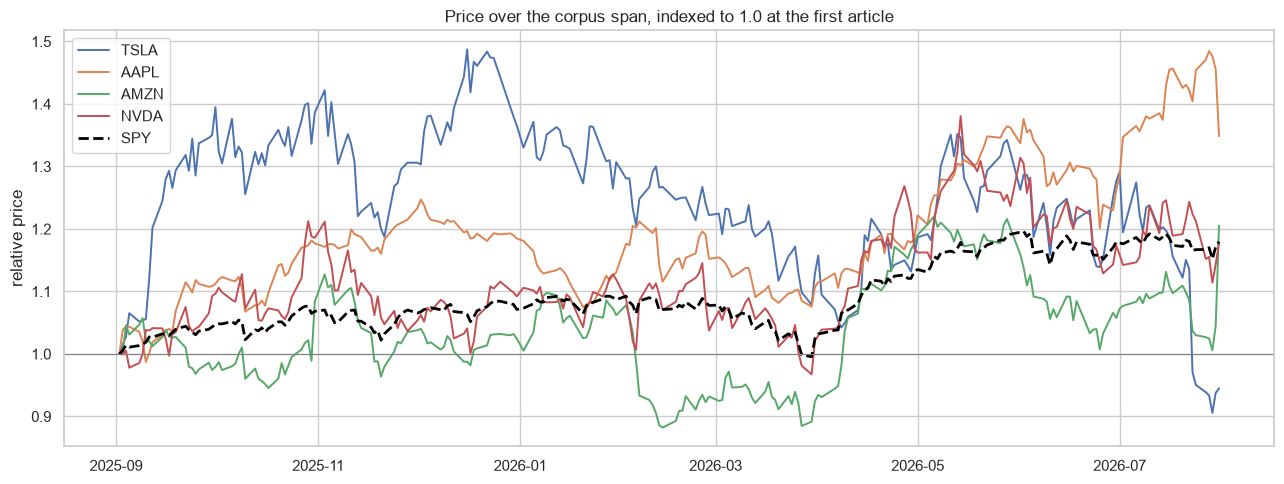

In [6]:
close = split_ohlcv(pd.read_parquet(RAW_OHLCV_PATH), TICKERS + ["SPY"])["close"]
lo, hi = pool["timestamp_utc"].min().normalize(), pool["timestamp_utc"].max().normalize()
window = close.loc[(close.index >= lo) & (close.index <= hi)]

summary = []
for c in TICKERS + ["SPY"]:
    s = window[c].dropna()
    summary.append(
        {
            "symbol": c,
            "start": round(s.iloc[0], 2),
            "end": round(s.iloc[-1], 2),
            "change": f"{s.iloc[-1] / s.iloc[0] - 1:+.2%}",
            "low": round(s.min(), 2),
            "high": round(s.max(), 2),
        }
    )
print(pd.DataFrame(summary).to_string(index=False))

normalised = window[TICKERS + ["SPY"]] / window[TICKERS + ["SPY"]].iloc[0]
fig, ax = plt.subplots(figsize=(13, 5))
for c in TICKERS:
    ax.plot(normalised.index, normalised[c], label=c, linewidth=1.4)
ax.plot(normalised.index, normalised["SPY"], label="SPY", color="black", linewidth=2, linestyle="--")
ax.axhline(1.0, color="grey", linewidth=0.8)
ax.set_title("Price over the corpus span, indexed to 1.0 at the first article")
ax.set_ylabel("relative price")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.5-price-over-corpus.png", dpi=120)
plt.show()


Not four versions of the same story. AAPL rose 34.9%, AMZN 20.5% and NVDA 17.7% while SPY rose
18.0%, so two roughly matched the market and one clearly beat it. TSLA fell 5.5%, and it is the only
one of the four that finished below where it started.

TSLA is also the one that moved most along the way, from 298 to 490 and back, which is the same
round-trip year `3.0` described. The other three are closer to steady climbs.

This matters for what follows. A label built from ticker-minus-SPY return should lean negative on a
stock that underperformed and positive on one that beat the market, so the four tickers give four
different label balances to check that against, rather than one.


### 5. Label balance

Whether `label_direction` sits near 50/50 per ticker. A model beating a majority-class baseline near
50% is being tested honestly; one tested against a skewed label is not.

`3.0` section 5 found something it could not explain here. TSLA's old table leaned *positive*, 50.4%
up, on a stock that had underperformed SPY badly over the same window. A ticker-minus-SPY label
should lean the other way. It flagged that as worth investigating and moved on.


In [7]:
rows = []
for t in TICKERS:
    x = frames[t]
    s = window[t].dropna()
    rows.append(
        {
            "ticker": t,
            "up": f"{(x['label_direction'] > 0).mean():.1%}",
            "down": f"{(x['label_direction'] < 0).mean():.1%}",
            "flat": f"{(x['label_direction'] == 0).mean():.1%}",
            "price change": f"{s.iloc[-1] / s.iloc[0] - 1:+.2%}",
            "vs SPY": f"{(s.iloc[-1] / s.iloc[0]) - (window['SPY'].iloc[-1] / window['SPY'].iloc[0]):+.2%}",
            "mean abn return": f"{x['abnormal_return_1d'].mean():+.5f}",
        }
    )
balance = pd.DataFrame(rows)
print(balance.to_string(index=False))
print(f"\npooled: up {(pool['label_direction'] > 0).mean():.1%}, down {(pool['label_direction'] < 0).mean():.1%}")
print("\n3.0, old TSLA table: up 50.4% on a stock that underperformed SPY by roughly 24 points")


ticker    up  down flat price change  vs SPY mean abn return
  TSLA 46.4% 53.6% 0.0%       -5.51% -23.48%        -0.00179
  AAPL 51.2% 48.8% 0.0%      +34.85% +16.89%        +0.00032
  AMZN 49.0% 51.0% 0.0%      +20.52%  +2.55%        +0.00101
  NVDA 48.7% 51.3% 0.0%      +17.71%  -0.26%        +0.00008

pooled: up 48.7%, down 51.3%

3.0, old TSLA table: up 50.4% on a stock that underperformed SPY by roughly 24 points


The puzzle is resolved, and the answer is that the old skew was an artefact of the old corpus.

Every ticker now leans the way its price says it should. TSLA underperformed SPY and leans down,
46.4% up against 53.6% down. AAPL beat the market and is the only one of the four leaning up, 51.2%.
AMZN and NVDA roughly matched SPY and sit closest to even, 49.0% and 48.7%. The direction of the lean
tracks the sign of the excess return in all four cases.

`3.0`'s positive skew on a stock that fell was therefore not something wrong with the label
definition. It was 1,976 articles, clustered into about thirteen bursts, not sampling the year evenly
enough for the corpus-wide balance to reflect the year. The same label on the same stock over the
same window, sampled properly, leans the other way.

No ticker is far enough from 50/50 to make a baseline dishonest, and the pooled table sits at 48.7%
up. This is a fair test.


### 6. Is the corpus still bursty?

This is the root cause behind `3.2` and `3.3`. The old corpus published in bursts: 92 active days out
of 351, clustered into about thirteen groups of very different sizes, with gaps of up to 27 days.
That is what made `day_grouped_splits` produce test folds ranging 176 to 529 rows with majority
baselines swinging between 19.9% and 69.4%, which is what `3.3` spent a whole iteration fixing in the
harness rather than the model.

The fetch fix windowed the Finnhub pull by day instead of by month. This checks whether it worked on
the merged tables a model would actually see.


ticker  articles  span days  active days active share  longest gap  median per active day  max per day
  TSLA      9073        335          335       100.0%            0                     25          102
  AAPL      7041        335          328        97.9%            2                     17           90
  AMZN     11071        336          335        99.7%            1                     31          129
  NVDA     14113        335          333        99.4%            1                     40          127

3.2, old TSLA corpus: 1,976 articles, 92 active days of 351 (26.2%), longest gap 27 days


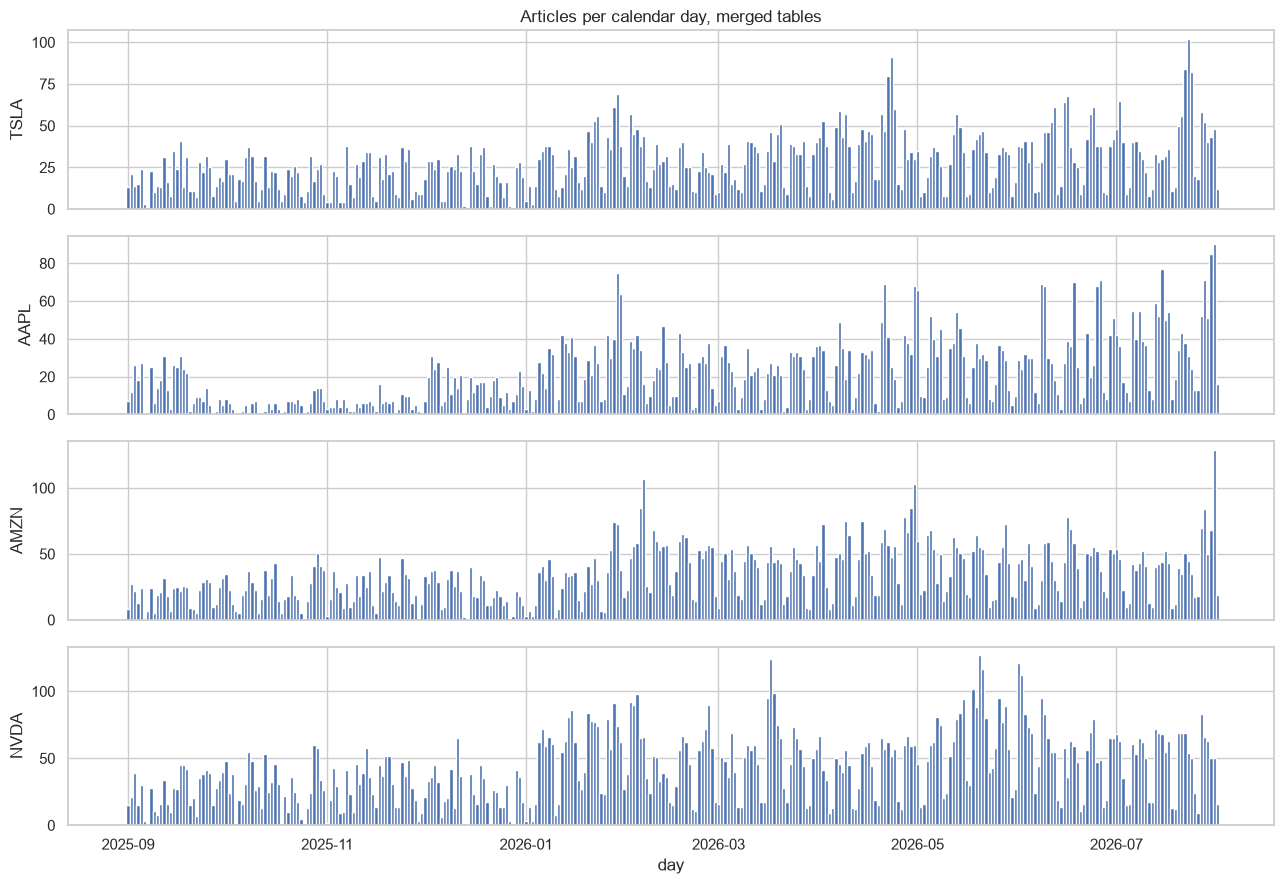

In [8]:
rows = []
daily_counts = {}
for t in TICKERS:
    day = frames[t]["timestamp_utc"].dt.tz_convert(None).dt.normalize()
    counts = day.value_counts().sort_index()
    full = pd.date_range(day.min(), day.max(), freq="D")
    counts = counts.reindex(full, fill_value=0)
    daily_counts[t] = counts

    longest, current = 0, 0
    for v in counts.to_numpy():
        current = current + 1 if v == 0 else 0
        longest = max(longest, current)

    active = int((counts > 0).sum())
    rows.append(
        {
            "ticker": t,
            "articles": len(frames[t]),
            "span days": len(counts),
            "active days": active,
            "active share": f"{active / len(counts):.1%}",
            "longest gap": longest,
            "median per active day": int(counts[counts > 0].median()),
            "max per day": int(counts.max()),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))
print("\n3.2, old TSLA corpus: 1,976 articles, 92 active days of 351 (26.2%), longest gap 27 days")

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, t in zip(axes, TICKERS):
    ax.bar(daily_counts[t].index, daily_counts[t].to_numpy(), width=1.0, color="#4C72B0")
    ax.set_ylabel(t)
axes[0].set_title("Articles per calendar day, merged tables")
axes[-1].set_xlabel("day")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.5-articles-per-day.png", dpi=120)
plt.show()


Fixed, and not marginally. Active-day coverage runs 97.9% to 100% against the old corpus's 26.2%,
and the longest gap anywhere is 2 days against the old 27. TSLA publishes on every single day of its
span. The charts show four dense bands rather than the thirteen separated clumps `3.2` was working
with.

Volume per day rose with it: a median of 17 to 40 articles on an active day, where the old corpus
averaged far fewer and concentrated them.

This removes the mechanism behind `3.2` section 3.1 and the whole of `3.3`. Whatever else this
corpus turns out to have wrong with it, uneven sampling across the year is no longer the thing
distorting the folds.


### 7. One model on all four, or four models?

Everything up to here has been about the four corpora as collected, and per ticker is the only way to
read those: prices are per company, collection happened per ticker, and section 5's finding only
exists per ticker. From here on the notebook is about the table a model gets trained and evaluated
on, and that needs deciding first, because folds and everything after depend on it.

The old corpus could not raise the question. With one ticker there was one table. With four there is
a choice: fit one model on all 41,298 rows, or fit four models on 7,041 to 14,113 rows each.

Two things have to hold before pooling is even an option. The rows have to be individually
addressable, and they have to be genuinely different training examples rather than the same one
repeated.


In [9]:
ids = {t: set(frames[t]["article_id"]) for t in TICKERS}
rows = []
for i, a in enumerate(TICKERS):
    for b in TICKERS[i + 1 :]:
        shared = ids[a] & ids[b]
        rows.append(
            {
                "pair": f"{a}-{b}",
                "shared": len(shared),
                "share of first": f"{len(shared) / len(ids[a]):.1%}",
                "share of second": f"{len(shared) / len(ids[b]):.1%}",
            }
        )
print(pd.DataFrame(rows).to_string(index=False))

per_article = pool.groupby("article_id").size().value_counts().sort_index()
print("\narticles appearing under N tickers:")
for n, count in per_article.items():
    print(f"  {n}: {count:,}")

print(f"\narticle_id alone unique in pooled? {not pool['article_id'].duplicated().any()}")
print(f"(article_id, ticker) unique?      {not pool.duplicated(['article_id', 'ticker']).any()}")
print(f"rows sharing an article with another row: {int(pool['article_id'].duplicated(keep=False).sum()):,} "
      f"({pool['article_id'].duplicated(keep=False).mean():.1%})")

multi = pool[pool["article_id"].duplicated(keep=False)]
print(f"\nof {multi['article_id'].nunique():,} multi-ticker articles:")
print(f"  {(multi.groupby('article_id')['label_direction'].nunique() > 1).sum():,} carry a different label depending on the ticker")
print(f"  {(multi.groupby('article_id')[SENTIMENT].nunique() > 1).sum():,} carry a different sentiment score depending on the ticker")


     pair  shared share of first share of second
TSLA-AAPL     803           8.9%           11.4%
TSLA-AMZN    1023          11.3%            9.2%
TSLA-NVDA    1135          12.5%            8.0%
AAPL-AMZN    1132          16.1%           10.2%
AAPL-NVDA    1408          20.0%           10.0%
AMZN-NVDA    1633          14.8%           11.6%

articles appearing under N tickers:
  1: 31,268
  2: 3,504
  3: 602
  4: 304

article_id alone unique in pooled? False
(article_id, ticker) unique?      True
rows sharing an article with another row: 10,030 (24.3%)

of 4,410 multi-ticker articles:
  2,522 carry a different label depending on the ticker
  4,383 carry a different sentiment score depending on the ticker


Finnhub returns one story for every ticker it mentions, so an article about several companies lands
in several tables. 4,410 articles appear under more than one ticker, 304 of them under all four, and
that makes 24.3% of pooled rows share their article with another row.

`article_id` alone is therefore not a key here. `(article_id, ticker)` is, which is the pair the merge
pipeline already writes and checks.

The rows are also genuinely different examples rather than copies. 4,383 of the 4,410 shared articles
carry a different sentiment score depending on which ticker they were scored for, because the text
layer scores toward the target, and 2,522 carry a different label, because the two companies moved
differently that day. Same story, different question, different answer.

Worth looking at directly, since "the same article" is a claim about text while the table holds
features.


In [10]:
a, b = frames["TSLA"], frames["NVDA"]
both = set(a["article_id"]) & set(b["article_id"])
A = a[a["article_id"].isin(both)].set_index("article_id").sort_index()
B = b[b["article_id"].isin(both)].set_index("article_id").sort_index()

rows = []
for c in A.columns:
    if c in ("ticker", "session_open"):
        continue
    if A[c].dtype.kind in "fi":
        same = np.isclose(A[c].astype(float), B[c].astype(float), equal_nan=True).mean()
    else:
        same = (A[c].astype(str) == B[c].astype(str)).mean()
    rows.append({"column": c, "identical across the two copies": f"{same:.1%}"})

print(f"the same article under TSLA and under NVDA, {len(both):,} of them\n")
print(pd.DataFrame(rows).to_string(index=False))


the same article under TSLA and under NVDA, 1,135 of them

                       column identical across the two copies
                timestamp_utc                           99.8%
                       source                          100.0%
                n_total_sents                           61.4%
               n_entity_sents                           42.6%
                  n_ceo_sents                           75.3%
          n_boilerplate_sents                           73.7%
                 entity_share                           33.9%
               article_length                           76.0%
    fus_conf_graft_floor_mean                            0.4%
  fus_conf_graft_floor_median                            0.4%
    fus_conf_graft_floor_lead                           36.6%
fus_conf_graft_floor_top3_pos                            0.4%
fus_conf_graft_floor_top3_neg                            0.4%
  fus_conf_graft_floor_spread                           61.4%
           

What the two copies share is provenance and shape: the same source always, the same timestamp almost
always, the same length 76% of the time. What they do not share is anything a model would key on.
Sentiment matches 0.4% of the time, no market feature ever matches, and the label matches 60%.

So a pooled model does see each shared story twice, but never as the same row. The cost is effective
sample size rather than duplication: a fold holding both copies carries slightly less independent
information than its row count suggests. It is not a leak, and section 8 confirms both copies always
land in the same fold anyway.

Against that, what pooling buys.


In [11]:
from stock_predictor.config import RAW_SCHEDULE_PATH
from stock_predictor.market.labels import align_sessions

# The market session each article is labelled against. Section 8 covers why this,
# and not the calendar day, is the unit that matters.
schedule = pd.read_parquet(RAW_SCHEDULE_PATH)
pool = pool.sort_values("timestamp_utc").reset_index(drop=True)
pool["session_open"] = align_sessions(pool["timestamp_utc"], schedule)
pool["calendar_day"] = pool["timestamp_utc"].dt.tz_convert(None).dt.normalize()
for t in TICKERS:
    frames[t]["session_open"] = align_sessions(frames[t]["timestamp_utc"], schedule)

print(f"pooled rows           : {len(pool):,}")
print(f"largest single ticker : {pool['ticker'].value_counts().max():,}")
print(f"smallest              : {pool['ticker'].value_counts().min():,}")
print(f"\nticker-sessions pooled: {pool.groupby(['session_open', 'ticker']).ngroups:,}")
print(f"sessions per ticker   : {pool.groupby('session_open').ngroups:,}")
print("3.4 aggregated to 71 sessions, which is why nothing it tried reached significance")

print("\nabnormal_return_1d by ticker, to check the four are on a comparable scale:")
print(pool.groupby("ticker")["abnormal_return_1d"].agg(["mean", "std"]).round(4).to_string())


pooled rows           : 41,298
largest single ticker : 14,113
smallest              : 7,041

ticker-sessions pooled: 924
sessions per ticker   : 231
3.4 aggregated to 71 sessions, which is why nothing it tried reached significance

abnormal_return_1d by ticker, to check the four are on a comparable scale:
          mean     std
ticker                
AAPL    0.0003  0.0191
AMZN    0.0010  0.0225
NVDA    0.0001  0.0198
TSLA   -0.0018  0.0274


Three times the data, and the four are on a comparable scale: standard deviations 0.019 to 0.027,
means near zero. This is not four different distributions being mashed together.

The number that decides it is 924. `3.4`'s session-level aggregation was the most promising thing it
tried, collapsing the fingerprint to chance and giving sentiment real weight in the tree, and it
failed on sample size with 71 sessions and folds of 10 to 13 rows. Pooled, the same aggregation has
924 ticker-sessions to work with. The config most likely to work is only viable pooled.

**Decision. Pool.** One model on all four tickers, keyed on `(article_id, ticker)`, with per-ticker
models kept as the comparison rather than the default. That is also the question that matters here, whether a model trained on news generalises across companies,
and a pooled fit answers it directly instead of by inference from four separate ones.

Sections 8 and 9, which are about the folds and what a model can shortcut, read the pooled table.
Sections 10 to 12 stay per ticker, because what they measure is per ticker: how well the text layer
scored each company, how much of each company each article actually covers, and a leakage check that
reconstructs each ticker's own price series.


### 8. The folds

`3.2` found the harness was the problem before it found any evidence of model skill: fold sizes ran
176 to 529 rows and majority baselines swung 19.9% to 69.4%, so a fold's accuracy meant nothing
next to another fold's. `3.3` fixed the sizing by cutting folds on row count instead of day count.

Two things to check on the pooled table. Whether the sizing fix holds, and whether the unit being
kept whole is the right one.

It is not, and it is worth being precise about why, because it is not simply a coarser version of the
right answer.

**What a row's label is built from.** `abnormal_return_1d` is not "the day after the article". It is
the return over the market session the article is anchored to, and `align_timestamp` anchors an
article to the first market open strictly after it publishes. So:

- an article published **before the bell** anchors to **that morning's** session;
- an article published **during market hours** anchors to the **next** session, because the current
  one is already under way and its open has passed;
- an article published **after the close** anchors to the **next** session too;
- and an article published on a **Friday evening, a Saturday, or a Sunday** all anchor to the
  **Monday** session.

Every article anchored to the same session gets the same return, the same label, and the same market
features. That set of rows is the thing that must not be divided.

**Why the calendar day is not that set.** It is wrong in both directions, which a coarse
approximation would not be.

*It merges rows that belong apart.* A single calendar day usually contains articles from two
different sessions. Anything published before that morning's bell is labelled against that day's
move; anything published after the bell is labelled against the next day's. Those are different
answers, and on this corpus they disagree often. Keeping such a day whole keeps together rows that
share nothing but a date.

*It separates rows that belong together.* An article published on Friday afternoon, one published on
Saturday, and one published early Monday all anchor to the Monday open. They carry one label and one
set of market features between them, spread across four calendar days. Day grouping treats those as
four independent blocks, so a fold boundary landing in the weekend puts rows with an identical
answer on both sides of a train/test split. That is precisely the leak the grouping exists to
prevent.

So the calendar day is not a rough proxy for the session. It cuts across sessions in one direction
and merges them in the other, and no amount of care about fold sizes fixes a group that is the wrong
shape. The session is the only unit that matches the label, because the session is what the label is
computed from.


In [12]:
spans = pool.groupby("session_open")["calendar_day"].nunique()
print(f"sessions drawing on more than one calendar day: {int((spans > 1).sum())} of {len(spans)}")
print(f"most calendar days feeding a single session   : {int(spans.max())}")
labels_per_session = pool.groupby(["session_open", "ticker"])["label_direction"].nunique()
print(f"distinct labels within one ticker-session     : {sorted(labels_per_session.unique())}")

rows = []
for name, groups in [("calendar day", pool["calendar_day"]), ("market session", pool["session_open"])]:
    sizes, balances = [], []
    fold = np.full(len(pool), -1)
    for i, (train, test) in enumerate(row_grouped_splits(groups, n_splits=5)):
        fold[test] = i
        sizes.append(int(test.sum()))
        balances.append((pool.loc[test, "label_direction"] > 0).mean())

    seen = pool[fold >= 0].assign(fold=fold[fold >= 0])
    straddled = int((seen.groupby("session_open")["fold"].nunique() > 1).sum())
    split_articles = int(
        (seen[seen["article_id"].duplicated(keep=False)].groupby("article_id")["fold"].nunique() > 1).sum()
    )

    rows.append(
        {
            "grouped by": name,
            "test rows": f"{min(sizes):,}-{max(sizes):,}",
            "spread": max(sizes) - min(sizes),
            "spread %": f"{(max(sizes) - min(sizes)) / np.mean(sizes):.1%}",
            "balance spread": f"{max(balances) - min(balances):.1%}",
            "sessions split": straddled,
            "shared articles split": split_articles,
        }
    )
print()
print(pd.DataFrame(rows).to_string(index=False))


sessions drawing on more than one calendar day: 231 of 231
most calendar days feeding a single session   : 5
distinct labels within one ticker-session     : [np.int64(1)]



    grouped by   test rows  spread spread % balance spread  sessions split  shared articles split
  calendar day 6,786-7,041     255     3.7%          10.9%               4                      0
market session 6,727-7,091     364     5.3%          11.0%               0                      0


Every session draws its articles from more than one calendar day, up to five across a long weekend,
and a ticker-session always carries exactly one label. So the calendar day was never the unit that
shares an answer. The session was, all along.

Grouping by calendar day splits sessions across fold boundaries, which puts rows carrying an
identical label and identical market features on both sides of a train/test split. Grouping by
session removes that, four straddled sessions down to none.

It costs a little fold evenness: the size spread goes from 3.7% to 5.3% of a fold, because sessions
are coarser blocks than days and a cut has fewer places to land. Label balance is unaffected, 10.9
points against 11.0. A correctness fix bought with a small precision cost, and `weighted_aggregate`
from `3.3` is already there to absorb that kind of unevenness.

It also settles the shared-article question from section 7. Not one multi-ticker article has its two
copies land in different folds, under either grouping, because the copies share a publication
timestamp and therefore a session. The overlap costs effective sample size and nothing else.

The pooled folds are healthier than any single ticker's, which is a second argument for pooling that
section 7 did not make. Label balance across folds spreads 11.0 points here, against 13.3 to 22.9
points for the individual tickers: a fold where one company had a bad ten weeks gets balanced by the
other three.

`row_grouped_splits` now takes the session directly, and `evaluate()` reads it from a `session_open`
column and raises if it is missing. There is no option to go back to day grouping, because day
grouping leaks.


### 9. The regime fingerprint

The most important finding in `3.2`, and the one `3.3` and `3.4` both failed to remove. Given only
market features and no text at all, a classifier could identify which fold a row came from with
99.6% accuracy against a 20% chance baseline. The model never had to read the article: it could
recognise which stretch of the year a row was from and answer whatever that stretch tended to do.

`3.4` got it to 22.2% by aggregating to sessions, but had only 71 sessions left, which is why nothing
reached significance.

Pooling adds a second version of the same worry. If market features can name the *ticker*, a pooled
model can answer "this looks like NVDA, and NVDA rose this quarter" without reading anything either.
Both are checked here, on the pooled table, under section 8's folds.


In [13]:
fold = np.full(len(pool), -1)
for i, (train, test) in enumerate(row_grouped_splits(pool["session_open"], n_splits=5)):
    fold[test] = i
seen = fold >= 0

clf = LGBMClassifier(n_estimators=100, num_leaves=31, verbose=-1, random_state=0)
fold_acc = cross_val_score(
    clf, pool.loc[seen, MARKET_FEATURES], fold[seen], cv=3, scoring="accuracy"
).mean()
ticker_acc = cross_val_score(
    LGBMClassifier(n_estimators=100, verbose=-1, random_state=0),
    pool[MARKET_FEATURES],
    pool["ticker"],
    cv=3,
).mean()

print(pd.DataFrame([
    {
        "target": "which fold a row is from",
        "rows": int(seen.sum()),
        "accuracy": f"{fold_acc:.1%}",
        "chance": f"{1 / len(np.unique(fold[seen])):.1%}",
        "lift": f"{fold_acc / (1 / len(np.unique(fold[seen]))):.1f}x",
    },
    {
        "target": "which ticker a row is",
        "rows": len(pool),
        "accuracy": f"{ticker_acc:.1%}",
        "chance": "25.0%",
        "lift": f"{ticker_acc / 0.25:.1f}x",
    },
]).to_string(index=False))
print("\n3.2 (old TSLA, article level): 99.6% against 20% chance, 5.0x")
print("3.4 (old TSLA, session level):  22.2% against 20% chance, 1.1x")


                  target  rows accuracy chance lift
which fold a row is from 34456    38.7%  20.0% 1.9x
   which ticker a row is 41298    53.6%  25.0% 2.1x

3.2 (old TSLA, article level): 99.6% against 20% chance, 5.0x
3.4 (old TSLA, session level):  22.2% against 20% chance, 1.1x


The fold fingerprint is much weaker than `3.2` measured and it is not gone. It comes down from 99.6%
for free: no aggregation, no lost rows, just a corpus that samples the year evenly. On the old corpus
a fold was a handful of separated bursts, so recognising a fold meant recognising a few distinct
market moments; now a fold is ten continuous weeks and the boundaries are much softer.

But it is still well above chance, and it always will be. Momentum and volatility are autocorrelated,
so nearby days resemble each other and distant ones do not. `3.2` said this was expected once stated
plainly, and nothing since has changed that.

The ticker fingerprint is the price of pooling, and it is real: market features identify which of the
four companies a row belongs to far better than chance. Volatility and beta are close to company
fingerprints by construction. A pooled model can lean on that instead of reading.

Neither is a reason to change the setup, and both are reasons to run the ablation `3.2` section 6.3
proposed: fit without the market-feature cluster and see how much of any result survives. No accuracy
number from iteration four should be reported without it.


### 10. Sentiment against the return

The check `3.0` section 8 ran, on four tickers. Correlation between the sentiment score and the
1-day abnormal return, and the directional accuracy of the score's sign against the label.

`3.0` measured 0.0358 correlation and 53.2% directional accuracy on the old TSLA table, and called
the 53.2% a small but real edge. The interesting question here is whether that number replicates on
4.6 times as much data for the same ticker, and whether the other three look like it.


ticker  rows   corr directional acc  scored rows
  TSLA  9073 0.0359           50.7%         8798
  AAPL  7041 0.0171           51.4%         6721
  AMZN 11071 0.0440           49.3%        10680
  NVDA 14113 0.0011           49.4%        13593
POOLED 41298 0.0296           50.0%        39792

3.0 (old TSLA, 1,976 rows): corr 0.0358, directional accuracy 53.2%


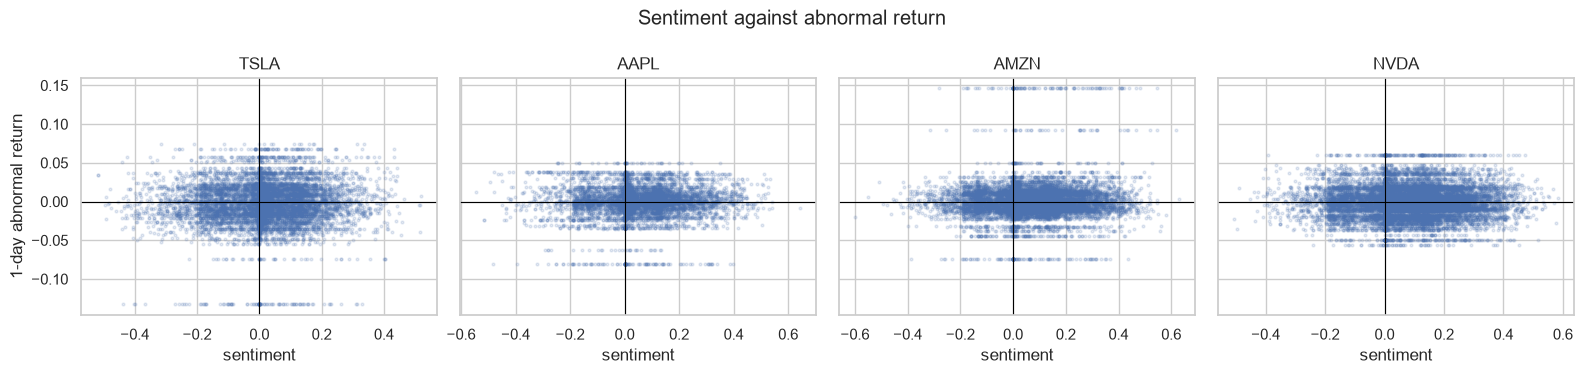

In [14]:
rows = []
for t in TICKERS:
    x = frames[t]
    c = x[[SENTIMENT, "abnormal_return_1d", "label_direction"]].dropna()
    c = c[c["label_direction"] != 0]
    scored = c[c[SENTIMENT] != 0]
    rows.append(
        {
            "ticker": t,
            "rows": len(c),
            "corr": round(c[SENTIMENT].corr(c["abnormal_return_1d"]), 4),
            "directional acc": f"{(np.sign(scored[SENTIMENT]) == scored['label_direction']).mean():.1%}",
            "scored rows": len(scored),
        }
    )
c = pool[[SENTIMENT, "abnormal_return_1d", "label_direction"]].dropna()
c = c[c["label_direction"] != 0]
scored = c[c[SENTIMENT] != 0]
rows.append(
    {
        "ticker": "POOLED",
        "rows": len(c),
        "corr": round(c[SENTIMENT].corr(c["abnormal_return_1d"]), 4),
        "directional acc": f"{(np.sign(scored[SENTIMENT]) == scored['label_direction']).mean():.1%}",
        "scored rows": len(scored),
    }
)
print(pd.DataFrame(rows).to_string(index=False))
print("\n3.0 (old TSLA, 1,976 rows): corr 0.0358, directional accuracy 53.2%")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, t in zip(axes, TICKERS):
    x = frames[t]
    ax.scatter(x[SENTIMENT], x["abnormal_return_1d"], s=4, alpha=0.15, color="#4C72B0")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(t)
    ax.set_xlabel("sentiment")
axes[0].set_ylabel("1-day abnormal return")
fig.suptitle("Sentiment against abnormal return")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.5-sentiment-vs-return.png", dpi=120)
plt.show()


TSLA's correlation replicates almost exactly: 0.0359 here against `3.0`'s 0.0358, on 4.6 times the
rows. A weak number measured twice on different samples of the same stock, landing in the same place,
is a more solid finding than the original was on its own.

The directional accuracy does not replicate. It falls from 53.2% to 50.7%, which is close enough to a
coin flip to be nothing. `3.0` called 53.2% a small but real edge; on the larger sample that edge is
mostly gone, and the honest conclusion is that 53.2% on 1,976 rows was not as solid as it looked.

Across the four, correlation runs from 0.0440 on AMZN down to 0.0011 on NVDA, and directional
accuracy sits between 49.3% and 51.4%. There is no ticker where sentiment on its own is a usable
signal, and NVDA is essentially zero on both measures. That is consistent with what the merge report
flagged about NVDA: it is named constantly in sector coverage that is not really about it, so its
sentiment scores are drawn from thinner and less relevant evidence than the others.

None of this means the text layer is worthless. It means a single score's sign is not a predictor by
itself, which is what a model with market features alongside it exists to find out.


### 11. Coverage per article, and whether shrinkage is still needed

`3.0` section 9.1 found that the sentiment mean was dominated by articles with exactly one sentence
about the target, and built the small-sample shrinkage fix for it. That fix now ships in the
pipeline, so these scores already carry it.

Two things to check. Whether single-sentence articles are still a large share of the corpus, and
whether the correlation is now spread across coverage levels rather than being carried by the thin
end.


In [15]:
rows = []
for t in TICKERS:
    x = frames[t]
    rows.append(
        {
            "ticker": t,
            "n_entity_sents == 1": int((x["n_entity_sents"] == 1).sum()),
            "share": f"{(x['n_entity_sents'] == 1).mean():.1%}",
            "median n_entity_sents": int(x["n_entity_sents"].median()),
            "mean entity_share": round(x["entity_share"].mean(), 3),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))
print("\n3.0 (old TSLA): 540 of 1,976 single-sentence (27.3%), mean entity_share 0.305")

bands = ["1", "2", "3-4", "5-8", "9+"]
out = {}
for t in TICKERS:
    x = frames[t]
    band = pd.cut(x["n_entity_sents"], [0, 1, 2, 4, 8, 10**6], labels=bands)
    out[t] = x.groupby(band, observed=True).apply(
        lambda g: g[SENTIMENT].corr(g["abnormal_return_1d"])
    )
by_band = pd.DataFrame(out).round(3)
print("\ncorrelation with abnormal_return_1d, by target-sentence count:")
print(by_band.to_string())


ticker  n_entity_sents == 1 share  median n_entity_sents  mean entity_share
  TSLA                 2424 26.7%                      4              0.308
  AAPL                 2277 32.3%                      3              0.269
  AMZN                 3759 34.0%                      2              0.238
  NVDA                 4261 30.2%                      3              0.224

3.0 (old TSLA): 540 of 1,976 single-sentence (27.3%), mean entity_share 0.305

correlation with abnormal_return_1d, by target-sentence count:
                 TSLA   AAPL   AMZN   NVDA
n_entity_sents                            
1               0.040  0.032  0.027  0.034
2              -0.009  0.022 -0.020 -0.035
3-4             0.052 -0.007  0.089 -0.022
5-8             0.078  0.042  0.063 -0.000
9+              0.023  0.024  0.041  0.019


Single-sentence articles are still a large share, 26.7% to 34.0%, so the problem `3.0` found has not
gone away with more data. It was never going to: it is a property of how financial news is written,
not of how much of it we collected.

The correlation by coverage band is the more useful read, and it says the shrinkage is doing its job
without fully solving the underlying issue. For TSLA, AAPL and AMZN the strongest correlations sit in
the middle and upper bands, 3-4 and 5-8 target sentences, rather than at the single-sentence end.
That is the right shape: articles with real coverage of the company carry more signal than articles
that mention it once. Under the raw score in `3.0` the thin end dominated instead.

NVDA is the exception again, and its bands are close to noise throughout, one of them negative.

The 9+ band being weaker than 5-8 for three of four tickers is worth noting but not acting on. Very
long articles about a company are often event coverage where the price move happened before
publication, which is a different problem from thin evidence and not one shrinkage addresses.


### 12. Leakage

Every feature has to pass one test: could this have been computed at the moment the article was
published. `3.0` section 11 found `momentum_1d` failing it on 75.8% of rows, which was the single
most consequential finding in that notebook, and section 11.1 confirmed the market layer's fix.

That check is no longer something a notebook has to remember to run. The merge pipeline reconstructs
`momentum_1d` from raw OHLCV on every run and refuses to stay quiet about a mismatch. This section
reads the result rather than repeating the work, and separately checks the labels are not sitting
inside the features.


In [16]:
for t in TICKERS:
    text = (report_dir("merge") / f"{t}_merge_report.md").read_text(encoding="utf-8")
    verdict = re.search(r"\| verdict \| \*\*(\w+)\*\*", text).group(1)
    matched = re.search(r"\| match the pre-publication formula \| ([\d,]+ \([\d.]+%\))", text).group(1)
    leaks = re.search(r"\| real leaks \| ([\d,]+)", text).group(1)
    print(f"{t}: {verdict}, {matched} match the pre-publication formula, {leaks} real leaks")

print("\ncorrelation of each market feature with the label it must not know:")
corrs = {
    c: round(pool[c].corr(pool["abnormal_return_1d"]), 4) for c in MARKET_FEATURES
}
print(pd.Series(corrs).sort_values(key=abs, ascending=False).to_string())


TSLA: pass, 9,726 (100.0%) match the pre-publication formula, 0 real leaks
AAPL: pass, 7,527 (100.0%) match the pre-publication formula, 0 real leaks
AMZN: pass, 12,096 (100.0%) match the pre-publication formula, 0 real leaks
NVDA: pass, 17,294 (100.0%) match the pre-publication formula, 0 real leaks

correlation of each market feature with the label it must not know:
news_volume            -0.0763
daily_range_ratio_1d    0.0748
beta_20d               -0.0492
relative_volume_20d     0.0426
momentum_1d             0.0313
volatility_20d         -0.0301
momentum_20d           -0.0299
momentum_5d            -0.0157
days_to_earnings       -0.0086


All four pass, on every row, with zero real leaks.

The feature correlations against the label back that up. The largest absolute correlation between any
market feature and `abnormal_return_1d` is `news_volume` at -0.076, and `momentum_1d` sits at 0.031,
nowhere near the 0.33 the pre-fix table showed when `3.0` first caught it. Nothing here has the
near-circular relationship a leaked feature produces.

`news_volume` being the largest is worth a note rather than an alarm. It counts articles published
before this one, so it is computable at publication time and is not a leak. A mild negative
relationship between how heavily a company was being covered and its next-day excess return is a
plausible real effect, and one iteration four can look at properly.

Worth being clear about what this does and does not cover. It verifies `momentum_1d` directly and
checks the rest for the symptom a leak would produce. The other rolling features are built by the
same code path with the same day cutoff, so the direct verification of one is reasonable evidence for
the family, but it is evidence rather than proof.


### 13. Limitations

Two things this notebook found are worth carrying forward as constraints rather than as bugs to fix.

**One article still competes with everything else in its session.** `3.0` section 12 raised this and
the larger corpus made it worse, not better. `abnormal_return_1d` is one number for a whole market
session, and a ticker-session now carries a median of 41 articles and as many as 218. Every one of
them gets that same number as its label. A single article's sentiment is being asked to explain a
move that dozens of others also contributed to, or cancelled out, and no feature in the table
separates "the one bearish article among forty bullish ones" from "one of forty equally bearish
ones". This is the strongest argument for `3.4`'s config 2, aggregating to the session, and the
reason it deserves a second run: it failed on sample size, and sample size is exactly what pooling
changed.

**The fingerprint is smaller but not gone, and pooling adds a second one.** Section 9 found market
features identifying which fold a row is from at 1.9 times chance and which ticker it is at 2.1
times. Both are much weaker than `3.2`'s 5.0, and neither is zero. Any result in iteration four needs
the ablation to show the model is not leaning on either.


### 14. Decision

**The corpus problems are fixed. The modelling problems are not, and are now measurable.**

What `3.2` through `3.4` blamed for their null results has genuinely gone away. The corpus samples
the year evenly, folds are even in size, label balance is honest per ticker and tracks each stock's
actual excess return, there is no leakage, and the sample is twenty times larger. `3.4`'s handoff has
been carried out in full.

What did not survive the larger sample is the sentiment edge itself. `3.0` measured 53.2%
directional accuracy on 1,976 TSLA articles and called it a small but real edge. On 39,792 pooled
rows it is 50.0%, a coin flip to one decimal place, and on TSLA alone it is 50.7%. The correlation
holds up better: 0.0296 pooled against `3.0`'s 0.0358, and 0.0359 on TSLA, which replicates almost
exactly on 4.6 times the data.

So the correlation was real and the accuracy figure was not. That is the correction more data is
supposed to deliver, and it resets what iteration four is aiming at: not a 53% edge to build on, but
a weak linear relationship a model has to find something to do with.

**Iteration four should re-run `3.4`'s three configurations against the pooled corpus, in the order
`3.4` left them:**

1. **Session-level aggregation first**, not last. It was `3.4`'s most promising result, it collapsed
   the fingerprint to chance, and its only failure was 71 sessions with folds of 10 to 13 rows.
   Pooled, there are 924 ticker-sessions. The objection that killed it is gone, and pooling is what
   removes it.
2. **Relative sentiment second.** It was the closest thing `3.4` had to significance and it costs
   little to re-test.
3. **The market/text ensemble third**, on whichever of the two above holds up.

**Pool, keyed on `(article_id, ticker)`.** One model on all four tickers, per-ticker models kept as
the comparison. Section 7 settles it: three times the data, the four returns on a comparable scale,
924 ticker-sessions instead of 71, and pooled folds whose label balance is steadier than any single
ticker's, 11.0 points against 13.3 to 22.9. The shared articles are real training examples rather
than duplicates, they never straddle a fold, and the cost is effective sample size rather than a
leak. The price is the ticker fingerprint, which the ablation below covers.

**Carry the ablation into every run.** Section 9 leaves two shortcuts open, worth roughly twice
chance each. No accuracy number from iteration four should be reported without the
fingerprint-cluster ablation beside it.

**Session-grouped folds are now the harness.** Section 8 found the splitter keeping the calendar day
whole while the label is built from the market session, which split four sessions across fold
boundaries and put rows carrying an identical answer on both sides. Grouping by session closes it for
a small cost in fold evenness. Nothing in iteration four needs to opt in: `row_grouped_splits` takes
the session and `evaluate()` reads a `session_open` column.

**Applied in this notebook, and upstream.**

- `has_ceo_mention` was rebuilt over the correct population in `frames` and `pool`, section 3.1.
  `stock_predictor/text/sentiment.py` gained `n_ceo_mention_sents` and derives the flag from it, so
  the next text run produces this natively. Until then a table read straight off disk carries the old
  flag, and anything starting from the parquet needs section 3.1's recomputation first.
- `row_grouped_splits` now takes the session as the unit it may not divide, and cuts folds at the
  nearest group boundary. `evaluate()` reads the session from a `session_open` column and raises if
  it is absent. Both in `stock_predictor/market/evaluate_v2.py`, with no switch back to day
  grouping, since day grouping leaks.


### 15. Save the corrected tables

One of this notebook's findings now ships in the pipeline. The other still lives only in memory, and
it breaks something for whoever reads the parquet next.

**`session_open` is fixed properly.** Section 8 established it as the unit a fold may not divide, and
`evaluate()` refuses to run without it. `market.labels` already computed the aligned session to build
the label and then threw it away; it now keeps it as a column, so it flows through
`market_features.parquet` into the merge and the tables on disk carry it. That needed no model run,
just re-running the market and merge pipelines, which is seconds.

**`has_ceo_mention` is not.** The flag on disk is still the broken one from section 3, true on 30.8%
of TSLA rows against the corrected 48.3%. `stock_predictor/text/sentiment.py` is fixed, but the fix
only reaches the data through a text pipeline run, and that is hours of GPU time for a one-column
change. Anyone loading the merged table today silently trains on a flag that is wrong a third of the
time.

So this writes corrected tables, the same way `3.0` section 14 wrote its model-ready table rather
than leaving its corrections as instructions for someone else to remember. Written beside the
pipeline's own output rather than over it, so the pipeline's output stays exactly what the pipeline
produces:

    data/processed/merged/{TICKER}/model_ready.parquet
    data/processed/merged/model_ready_pooled.parquet


In [17]:
out_dir = PROCESSED_DATA_DIR / "merged"

written = []
for t in TICKERS:
    corrected = frames[t]
    path = out_dir / t / "model_ready.parquet"
    corrected.to_parquet(path, index=False)
    written.append(
        {
            "file": f"merged/{t}/model_ready.parquet",
            "rows": len(corrected),
            "columns": len(corrected.columns),
            "has_ceo_mention": f"{corrected['has_ceo_mention'].mean():.1%}",
        }
    )

pooled_out = pool.drop(columns=["calendar_day"])
pooled_path = out_dir / "model_ready_pooled.parquet"
pooled_out.to_parquet(pooled_path, index=False)
written.append(
    {
        "file": "merged/model_ready_pooled.parquet",
        "rows": len(pooled_out),
        "columns": len(pooled_out.columns),
        "has_ceo_mention": f"{pooled_out['has_ceo_mention'].mean():.1%}",
    }
)
print(pd.DataFrame(written).to_string(index=False))

check = pd.read_parquet(pooled_path)
original = (
    pd.read_parquet(out_dir / "pooled.parquet")
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

print()
print(f"reloaded pooled table: {check.shape}")
print(f"  session_open present       : {'session_open' in check.columns}")
print(f"  has_ceo_mention corrected  : {check['has_ceo_mention'].mean():.1%}")
print(f"  pipeline output was        : {original['has_ceo_mention'].mean():.1%}")
print(f"  (article_id, ticker) unique: {not check.duplicated(['article_id', 'ticker']).any()}")

untouched = [c for c in original.columns if c != "has_ceo_mention"]
print(f"  every other column unchanged: {check[untouched].equals(original[untouched])}")


                             file  rows  columns has_ceo_mention
  merged/TSLA/model_ready.parquet  9073       37           48.3%
  merged/AAPL/model_ready.parquet  7041       37           16.3%
  merged/AMZN/model_ready.parquet 11071       37           12.4%
  merged/NVDA/model_ready.parquet 14113       37           18.4%
merged/model_ready_pooled.parquet 41298       37           23.0%

reloaded pooled table: (41298, 37)
  session_open present       : True
  has_ceo_mention corrected  : 23.0%
  pipeline output was        : 12.4%
  (article_id, ticker) unique: True
  every other column unchanged: True


The tables reload clean: `has_ceo_mention` reports the share section 3.1 established, and every other
column is byte-identical to the pipeline's own output.

**What still has to happen upstream.** One thing, now. A text pipeline run per ticker is what puts
the corrected `has_ceo_mention` into `article_features.parquet`, and from there into the merge. Until
that happens the next merge run regenerates `merged.parquet` with the old flag, and these
`model_ready` files will not update alongside it.

Iteration four can start from these files today. It should not still be reading them once the text
layer has been re-run.
